Computing: qubits=2, layers=1
  Variance = 9.0804e-02 ± 7.4205e-02
Computing: qubits=2, layers=2
  Variance = 1.0465e-01 ± 7.3948e-02
Computing: qubits=2, layers=3
  Variance = 6.8767e-02 ± 7.5754e-02
Computing: qubits=2, layers=4
  Variance = 7.6743e-02 ± 4.6769e-02
Computing: qubits=3, layers=1
  Variance = 6.6067e-02 ± 5.8782e-02
Computing: qubits=3, layers=2
  Variance = 2.6390e-02 ± 2.1609e-02
Computing: qubits=3, layers=3
  Variance = 3.0194e-02 ± 1.4045e-02
Computing: qubits=3, layers=4
  Variance = 1.8736e-02 ± 1.1483e-02
Computing: qubits=4, layers=1
  Variance = 3.1668e-02 ± 1.7870e-02
Computing: qubits=4, layers=2
  Variance = 3.2217e-02 ± 2.4173e-02
Computing: qubits=4, layers=3
  Variance = 1.5790e-02 ± 1.2574e-02
Computing: qubits=4, layers=4
  Variance = 9.6538e-03 ± 6.8034e-03
Computing: qubits=5, layers=1
  Variance = 2.0631e-02 ± 1.4296e-02
Computing: qubits=5, layers=2
  Variance = 1.1509e-02 ± 6.9784e-03
Computing: qubits=5, layers=3
  Variance = 1.5533e-02 ± 2.4796

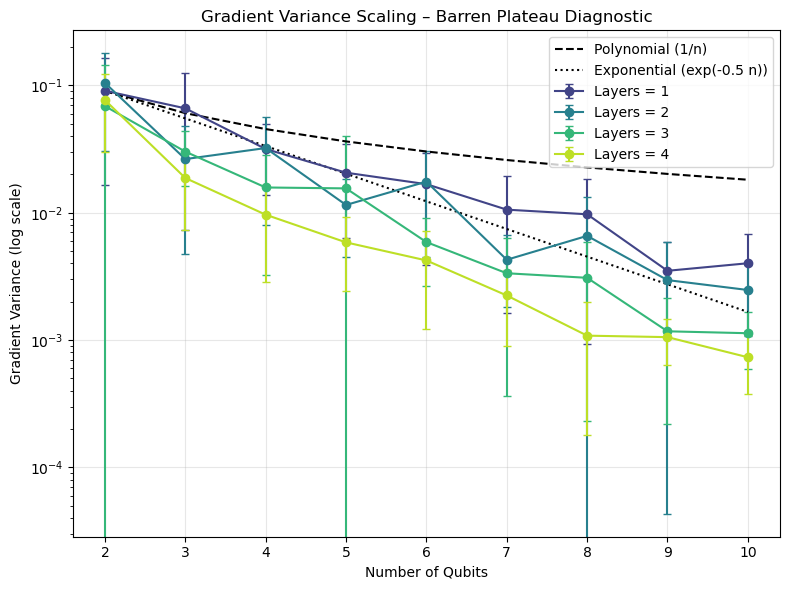

In [ ]:
# experiment_barren_plateau.py
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from core import QuantumModel, set_seed, generate_multifreq_data

def compute_gradient_variances(model, dataloader, n_samples=10, n_batches=5):
    """
    Estimate mean and std of gradient variances over random initializations.
    For each initialization, we average over a few batches to get a stable estimate.
    """
    device = next(model.parameters()).device
    variances = []  # list of gradient variances per initialization

    for _ in range(n_samples):
        # Re-initialize model parameters
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
        # Ensure circuit_weights are re-initialized (they are nn.Parameter)
        with torch.no_grad():
            model.circuit_weights.data = 0.1 * torch.randn_like(model.circuit_weights)

        batch_grads = []
        # Collect gradients from several batches
        for i, (X_batch, y_batch) in enumerate(dataloader):
            if i >= n_batches:
                break
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Dummy optimizer (SGD with zero momentum, just to get gradients)
            optimizer = torch.optim.SGD(model.parameters(), lr=1.0)
            loss_fn = torch.nn.MSELoss()

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()

            # Flatten all gradients into a single vector
            grads = []
            for p in model.parameters():
                if p.grad is not None:
                    grads.append(p.grad.view(-1).cpu().numpy())
            grads = np.concatenate(grads)
            batch_grads.append(grads)

        # Compute variance of gradients across all parameters and batches
        # (variance of the pooled gradient vector)
        all_grads = np.concatenate(batch_grads)  # shape: (total_params * n_batches,)
        var = np.var(all_grads)
        variances.append(var)

    return np.mean(variances), np.std(variances)

set_seed(42)

# Configuration
qubit_list = [2,3, 4,5, 6,7, 8,9, 10]       # number of qubits
layer_list = [1, 2, 3, 4]            # number of layers
input_dim = 1
n_samples_per_config = 10            # number of random initializations
n_batches = 5                        # number of batches per initialization

# Create a fixed dataset (small, just to have some inputs)
X, y = generate_multifreq_data(n_samples=500, noise=0.0, random_state=42)
dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Store results: a 2D array of (mean, std) for each (qubits, layers)
results_mean = np.zeros((len(qubit_list), len(layer_list)))
results_std = np.zeros_like(results_mean)

for i, nq in enumerate(qubit_list):
    for j, nl in enumerate(layer_list):
        print(f"Computing: qubits={nq}, layers={nl}")
        model = QuantumModel(n_qubits=nq, n_layers=nl, input_dim=input_dim)
        mean_var, std_var = compute_gradient_variances(
            model, dataloader,
            n_samples=n_samples_per_config,
            n_batches=n_batches
        )
        results_mean[i, j] = mean_var
        results_std[i, j] = std_var
        print(f"  Variance = {mean_var:.4e} ± {std_var:.4e}")

# Plotting
plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(layer_list)))

for j, nl in enumerate(layer_list):
    means = results_mean[:, j]
    stds = results_std[:, j]
    plt.errorbar(qubit_list, means, yerr=stds, label=f'Layers = {nl}',
                    color=colors[j], marker='o', capsize=3)

# Add reference lines
# Polynomial decay: 1 / n (normalized to match first point)
poly_ref = 1.0 / np.array(qubit_list)
poly_ref = poly_ref / poly_ref[0] * results_mean[0, 0]  # scale to first point
plt.plot(qubit_list, poly_ref, 'k--', label='Polynomial (1/n)')

# Exponential decay: exp(-alpha * n), choose alpha so that it decays visibly
alpha = 0.5
exp_ref = np.exp(-alpha * np.array(qubit_list))
exp_ref = exp_ref / exp_ref[0] * results_mean[0, 0]
plt.plot(qubit_list, exp_ref, 'k:', label=f'Exponential (exp(-{alpha} n))')

plt.yscale('log')
plt.xlabel('Number of Qubits')
plt.ylabel('Gradient Variance (log scale)')
plt.title('Gradient Variance Scaling – Barren Plateau Diagnostic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('experiment_barren_plateau.png', dpi=300)
plt.savefig('experiment_barren_plateau.pdf', dpi=300)
plt.show()

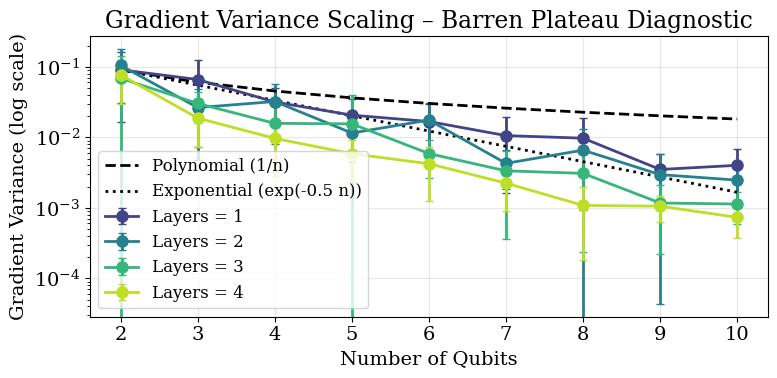

In [ ]:

# Plotting
plt.figure(figsize=(8, 4))

plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.family'] = 'serif'

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(layer_list)))

for j, nl in enumerate(layer_list):
    means = results_mean[:, j]
    stds = results_std[:, j]
    plt.errorbar(qubit_list, means, yerr=stds, label=f'Layers = {nl}',
                    color=colors[j], marker='o', capsize=3)

# Add reference lines
# Polynomial decay: 1 / n (normalized to match first point)
poly_ref = 1.0 / np.array(qubit_list)
poly_ref = poly_ref / poly_ref[0] * results_mean[0, 0]  # scale to first point
plt.plot(qubit_list, poly_ref, 'k--', label='Polynomial (1/n)')

# Exponential decay: exp(-alpha * n), choose alpha so that it decays visibly
alpha = 0.5
exp_ref = np.exp(-alpha * np.array(qubit_list))
exp_ref = exp_ref / exp_ref[0] * results_mean[0, 0]
plt.plot(qubit_list, exp_ref, 'k:', label=f'Exponential (exp(-{alpha} n))')

plt.yscale('log')
plt.xlabel('Number of Qubits')
plt.ylabel('Gradient Variance (log scale)')
plt.title('Gradient Variance Scaling – Barren Plateau Diagnostic')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('experiment_barren_plateau.png', dpi=300)
plt.savefig('experiment_barren_plateau.pdf', dpi=300)
plt.show()
